In this problem, you will perform K-means clustering manually, with K = 2, on a small example with n = 6 observations and p = 2 features. The observations are as follows.
(a) Plot the observations.

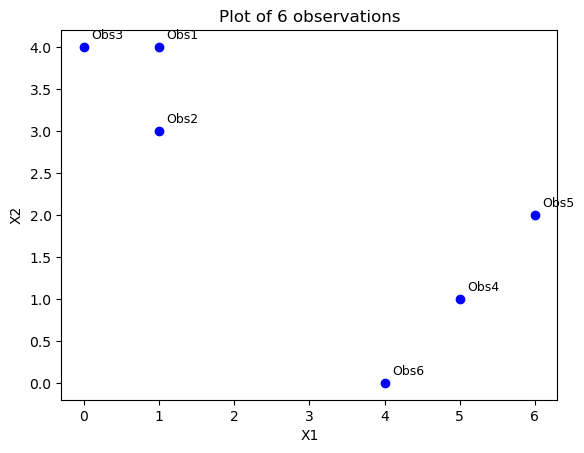

In [17]:
import matplotlib.pyplot as plt

# 觀測資料點的座標
X = np.array([
    [1, 4],  # Observations: (X1, X2)
    [1, 3],
    [0, 4],
    [5, 1],
    [6, 2],
    [4, 0]
])

# 提取 X1 和 X2 的座標
X1 = [point[0] for point in X]
X2 = [point[1] for point in X]

# 繪製散點圖
plt.scatter(X1, X2, color='blue')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Plot of 6 observations')
for i, (x, y) in enumerate(zip(X1, X2), start=1):
    plt.text(x + 0.1, y + 0.1, f'Obs{i}', fontsize=9)

plt.show()

(b) Randomly assign a cluster label to each observation. You can use the np.random.choice() function to do this. Report the cluster labels for each observation.

In [3]:
import numpy as np

# 設定觀測數量
n_observations = 6

# 使用 np.random.choice() 隨機挑選簇標籤（假設只有簇 1 和簇 2）
cluster_labels = np.random.choice([1, 2], size=n_observations)

# 輸出每個觀測的簇標籤
for i, label in enumerate(cluster_labels, start=1):
    print(f'Observation {i} assigned to cluster {label}')

Observation 1 assigned to cluster 1
Observation 2 assigned to cluster 2
Observation 3 assigned to cluster 2
Observation 4 assigned to cluster 2
Observation 5 assigned to cluster 1
Observation 6 assigned to cluster 1


(c) Compute the centroid for each cluster.

In [19]:
# 假設你已經有一個簇標籤
labels = np.array([1, 2, 2, 2, 1, 1])  # 範例，已正確為np.array

# 計算每個簇的中心
for cluster in np.unique(labels):
    points_in_cluster = X[labels == cluster]  # 這裡的條件符合
    centroid = points_in_cluster.mean(axis=0)
    print(f"Centroid of cluster {cluster}: {centroid}")

Centroid of cluster 1: [3.66666667 2.        ]
Centroid of cluster 2: [2.         2.66666667]


(d) Assign each observation to the centroid to which it is closest, in terms of Euclidean distance. Report the cluster labels for each observation.

In [21]:
cluster_centroids = {
    1: np.array([3.66666667,2. ]),  # 簇1的中心
    2: np.array([2.,2.66666667])      # 簇2的中心
} 

unique_clusters = np.unique(labels)
cluster_centroids = {cl: X[labels == cl].mean(axis=0) for cl in unique_clusters}

# 將每個觀測點指派到最近的中心
assigned_labels = []
for point in X:
    # 計算此點與所有centroids的距離
    distances = {cl: np.linalg.norm(point - centroid) for cl, centroid in cluster_centroids.items()}
    # 選擇距離最小的簇
    closest_cluster = min(distances, key=distances.get)
    assigned_labels.append(closest_cluster)

# 輸出結果
for i, label in enumerate(assigned_labels, start=1):
    print(f'Observation {i} is assigned to cluster {label}')

Observation 1 is assigned to cluster 2
Observation 2 is assigned to cluster 2
Observation 3 is assigned to cluster 2
Observation 4 is assigned to cluster 1
Observation 5 is assigned to cluster 1
Observation 6 is assigned to cluster 1


(e) Repeat (c) and (d) until the answers obtained stop changing.

In [23]:
# 初始簇標籤（可以用隨機或預設值）
np.random.seed(0)  # 為了重現
labels = np.random.choice([1, 2], size=6)

print("Initial labels:", labels)

while True:
    # (c) 計算每個簇的中心
    unique_clusters = np.unique(labels)
    centroids = {cl: X[labels == cl].mean(axis=0) for cl in unique_clusters}
    
    # (d) 重新分配簇
    new_labels = np.zeros_like(labels)
    for i, point in enumerate(X):
        distances = {cl: np.linalg.norm(point - centroid) for cl, centroid in centroids.items()}
        new_labels[i] = min(distances, key=distances.get)
    
    # 檢查是否收斂（簇標籤未改變）
    if np.array_equal(new_labels, labels):
        break
    # 更新簇標籤
    labels = new_labels
    print("Updated labels:", labels)

# 最終簇標籤
print("Converged cluster labels:", labels)

# 顯示每個簇的中心
for cl in np.unique(labels):
    print(f"Cluster {cl} centroid: {centroids[cl]}")

Initial labels: [1 2 2 1 2 2]
Updated labels: [2 2 2 1 1 2]
Updated labels: [2 2 2 1 1 1]
Converged cluster labels: [2 2 2 1 1 1]
Cluster 1 centroid: [5. 1.]
Cluster 2 centroid: [0.66666667 3.66666667]


(f) In your plot from (a), color the observations according to the cluster labels obtained.

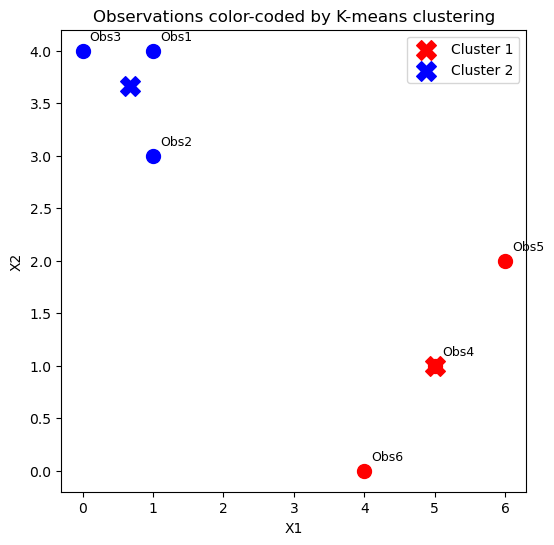

In [29]:
# 3. 定義不同簇的顏色和標籤
colors = ['red', 'blue']
cluster_labels = ['Cluster 1', 'Cluster 2']
cluster_colors = {cl: colors[i] for i, cl in enumerate(np.unique(labels))}

# 繪圖設定
plt.figure(figsize=(6, 6))
for i, point in enumerate(X):
    plt.scatter(point[0], point[1], color=cluster_colors[labels[i]], s=100)
    plt.text(point[0] + 0.1, point[1] + 0.1, f'Obs{i+1}', fontsize=9)

# 繪製簇中心點
for cl in np.unique(labels):
    plt.scatter(*centroids[cl], color=cluster_colors[cl], marker='X', s=200, label=f'{cluster_labels[list(np.unique(labels)).index(cl)]}')

# 添加圖例
plt.legend()
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Observations color-coded by K-means clustering')
plt.show()